# Explore GSE244921 — Cherief et al. 2023 scRNA-seq

**Two conditions:** TrkAWT (Control, innervated) vs TrkAF592A (INMPP1, denervated)  
**Total cells:** ~22,000 | **Pooled N=3 mice per genotype**  
**Goal:** Confirm cell type recovery, find TSPC cluster (Tppp3+Pdgfra+) and T-FAP-like population

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.settings.figdir = '../../figures/Cherief_scRNA-seq/'

import os
os.makedirs('../../figures/Cherief_scRNA-seq', exist_ok=True)

## 1. Load data

Files use non-standard prefixes so we rename them temporarily for `read_10x_mtx`.

In [2]:
import shutil, pathlib

def load_sample(src_dir, condition_label):
    src = pathlib.Path(src_dir)
    tmp = pathlib.Path(f'../../data/Cherief_scRNA-seq/tmp_{condition_label}')
    tmp.mkdir(exist_ok=True)
    for f in src.iterdir():
        if 'barcodes' in f.name:
            shutil.copy(f, tmp / 'barcodes.tsv.gz')
        elif 'features' in f.name:
            shutil.copy(f, tmp / 'features.tsv.gz')
        elif 'matrix' in f.name:
            shutil.copy(f, tmp / 'matrix.mtx.gz')
    adata = sc.read_10x_mtx(tmp, var_names='gene_symbols', cache=False)
    adata.obs['condition'] = condition_label
    return adata

control = load_sample('../../data/Cherief_scRNA-seq/GSM7832064_Control', 'TrkAWT')
inmpp1  = load_sample('../../data/Cherief_scRNA-seq/GSM7832065_INMPP1',  'TrkAF592A')

for d in ['../../data/Cherief_scRNA-seq/tmp_TrkAWT', '../../data/Cherief_scRNA-seq/tmp_TrkAF592A']:
    if pathlib.Path(d).exists():
        shutil.rmtree(d, ignore_errors=True)

print('Control cells:', control.n_obs)
print('INMPP1 cells: ', inmpp1.n_obs)

Control cells: 14868
INMPP1 cells:  10677


## 2. Merge and basic QC

c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Total cells: 25545 | Genes: 32285


C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\4182592879.py:9: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],


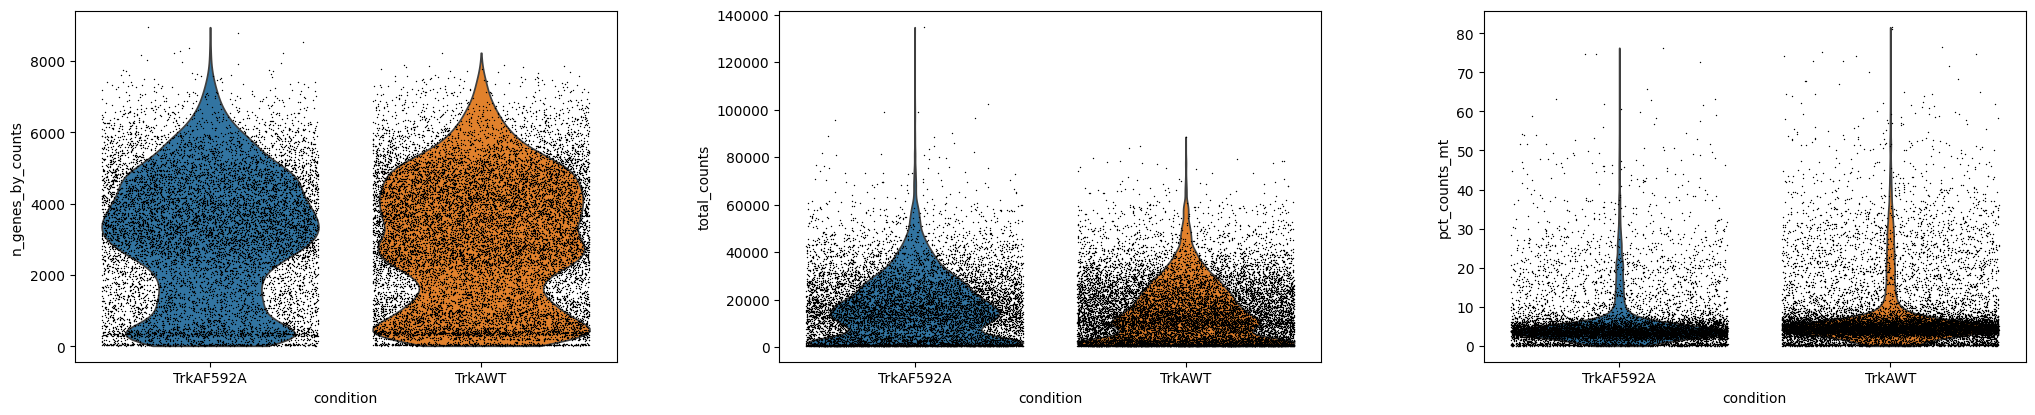

In [3]:
adata = sc.concat([control, inmpp1], label='sample', keys=['Control', 'INMPP1'])
adata.obs_names_make_unique()
print('Total cells:', adata.n_obs, '| Genes:', adata.n_vars)

# Flag mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='condition', jitter=0.4, multi_panel=True,
             save='_qc.png')

**QC violin plots** (`violin_qc.png`)

Three metrics are shown per condition (TrkAWT = orange, TrkAF592A = blue):

- **n_genes_by_counts (left):** Number of unique genes per cell. The bulk of cells fall between 1,000–5,000 genes — normal for healthy single cells. The spike extending above 7,000 genes represents likely doublets (two cells captured as one).
- **total_counts (middle):** Total RNA molecules (UMIs) per cell. Most cells sit around 10,000–40,000. The extreme outliers above 80,000 are also doublets.
- **pct_counts_mt (right):** Percentage of reads from mitochondrial genes. Healthy cells cluster near 0–10%. The long upper tail (reaching ~80%) represents dying or damaged cells whose cytoplasmic RNA has leaked out, leaving mostly mitochondrial signal.

Both conditions show nearly identical distributions — neither sample is systematically lower quality.

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\3615498746.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color='condition',


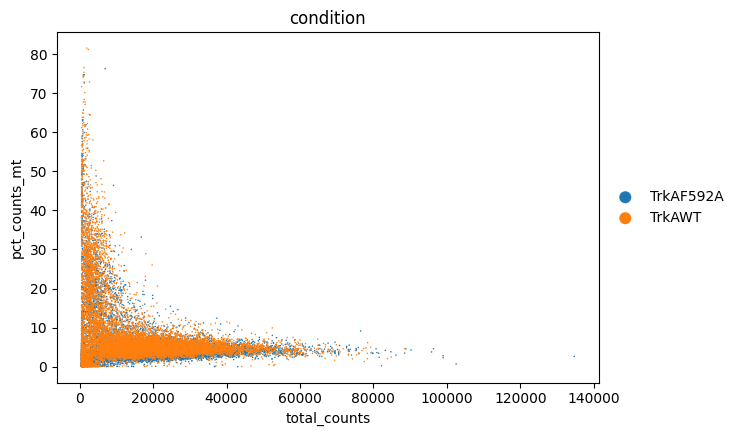

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\3615498746.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='condition',


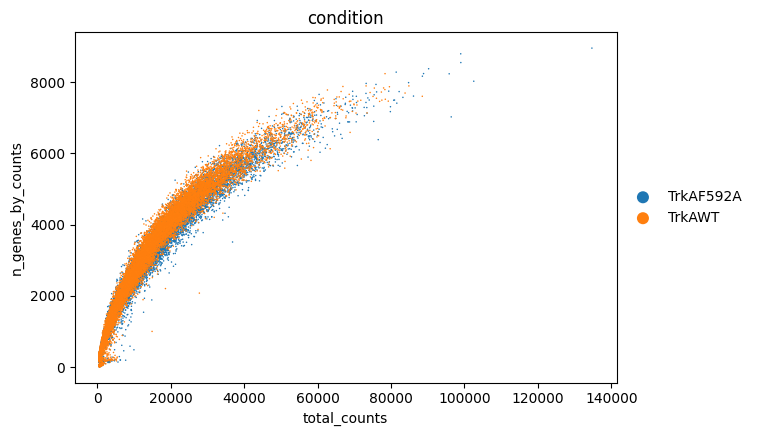

In [4]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color='condition',
              save='_mito.png')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='condition',
              save='_genes.png')

**QC scatter plots** (`scatter_mito.png`, `scatter_genes.png`)

- **total_counts vs pct_counts_mt:** Shows the classic "L-shape" of good-quality scRNA-seq. Cells in the bottom-right (high counts, low mito%) are high-quality. The upper-left arm (low counts, high mito%) represents damaged cells — their cytoplasmic RNA leaked out, leaving mostly mitochondrial reads. The 20% mito cutoff cleanly removes this arm. Both conditions overlap tightly, confirming no systematic quality difference between samples.

- **total_counts vs n_genes_by_counts:** Shows a smooth saturation curve — as you sequence more RNA per cell, you detect more unique genes, but with diminishing returns. This expected shape confirms data integrity. The main cloud plateaus around 5,000–6,500 genes at typical sequencing depths. Cells far above the curve at high counts are doublets. The filter at 7,500 genes removes these outliers while preserving the high end of the genuine distribution.

## 3. Filter low-quality cells

Adjust thresholds based on the QC plots above.

In [5]:
print('Before filtering:', adata.n_obs)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 20].copy()
adata = adata[adata.obs['n_genes_by_counts'] < 7500].copy()  # raised from 6000 based on QC scatter

print('After filtering: ', adata.n_obs)

Before filtering: 25545
filtered out 1057 cells that have less than 200 genes expressed
filtered out 10524 genes that are detected in less than 3 cells
After filtering:  22615


## 4. Normalize and embed

normalizing counts per cell
    finished (0:00:02)
extracting highly variable genes
    finished (0:00:04)


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:05)


C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\1291647237.py:11: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata, n_pcs=30, save='.png')


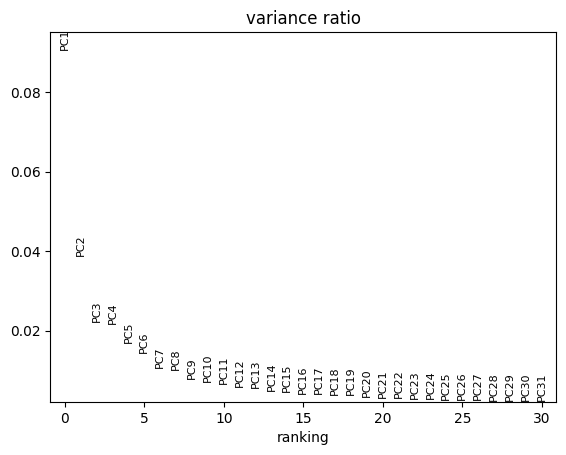

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Store log-normalised counts before scaling — required for pySCENIC and interpretable expression values
adata.raw = adata

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='condition')
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, n_pcs=30, save='.png')

**PCA variance ratio** (`pca_variance_ratio.png`)

Shows how much of the total gene expression variance each principal component (PC) explains. PC1 explains ~9%, PC2 ~4%, and variance drops steeply through PC5–6, then levels off into a flat "elbow" from ~PC10 onward. This means the first 10–20 PCs capture the major sources of biological variation, while later PCs mostly capture noise. Using 20 PCs for the neighbor graph (next step) is appropriate — it includes all informative signal without inflating the embedding with noise.

In [7]:
sc.pp.neighbors(adata, n_pcs=20)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished (0:00:31)
computing UMAP
    finished (0:00:07)
running Leiden clustering
    finished (0:00:00)


## 5. Visualize clusters

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\569706282.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=['leiden', 'condition'], legend_loc='on data',


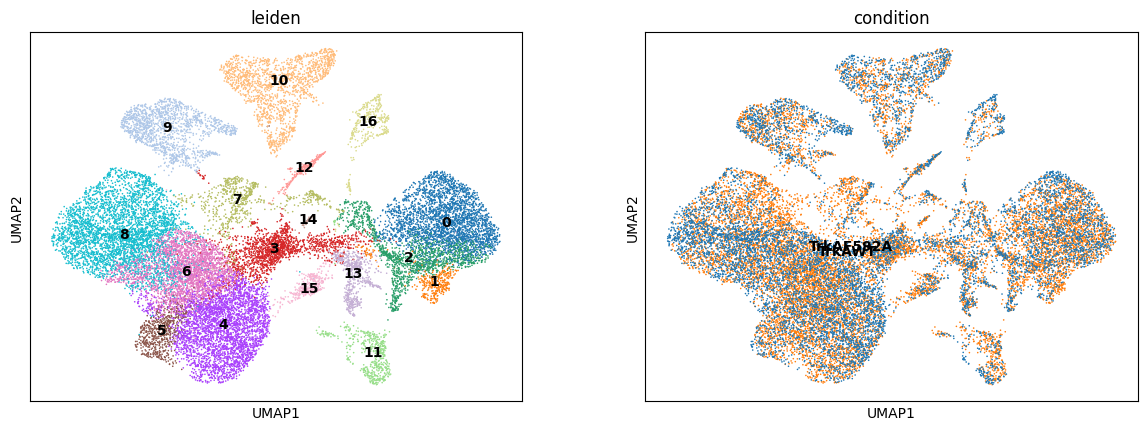

In [8]:
sc.pl.umap(adata, color=['leiden', 'condition'], legend_loc='on data',
           save='_clusters.png')

**UMAP — clusters and condition** (`umap_clusters.png`)

UMAP projects the 22,000+ cells into 2D, placing transcriptionally similar cells near each other.

- **Left (leiden clusters):** 17 clusters (0–16) are detected at resolution 0.5. The layout shows a large central mass of closely related clusters (likely mesenchymal cell types) with several smaller satellite clusters at the periphery — consistent with the paper's description of 4 mesenchymal subclusters plus immune and endothelial populations.
- **Right (condition):** TrkAWT (orange) and TrkAF592A (blue) cells are largely interleaved across the UMAP, meaning cluster identity is driven by cell type, not sample of origin. This is the expected result — both genotypes contain the same cell types, just in different proportions. The next steps identify which clusters shift between conditions.

## 6. Key marker genes

From Cherief Fig. 4 and Harvey 2019 — these identify the cell types we care about.

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\1376969396.py:15: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata, all_markers, groupby='leiden', standard_scale='var',


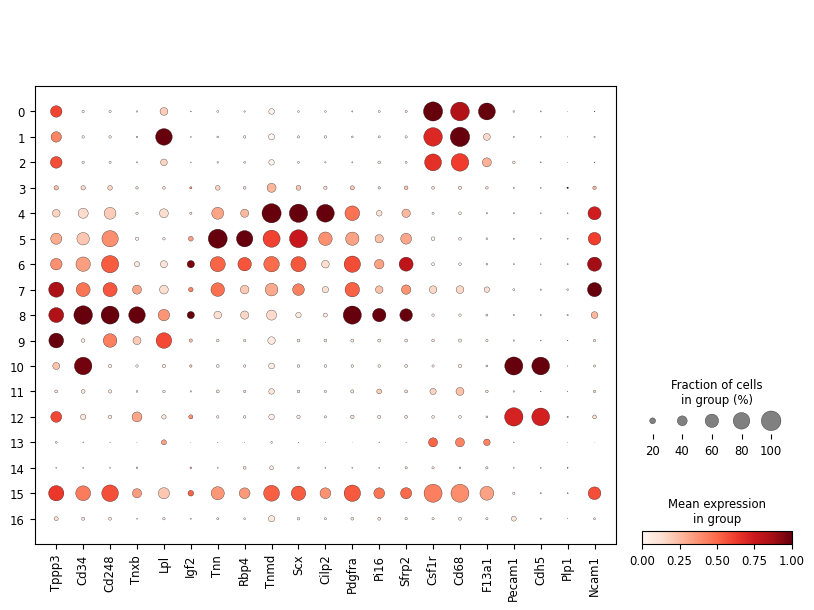

In [9]:
markers = {
    'TSPC / progenitor': ['Tppp3', 'Cd34', 'Cd248', 'Tnxb'],
    'Peripheral tendon':  ['Lpl', 'Igf2'],
    'Pretenocyte':        ['Tnn', 'Rbp4'],
    'Tenocyte':           ['Tnmd', 'Scx', 'Cilp2'],
    'T-FAP / fibrotic':   ['Pdgfra', 'Pi16', 'Sfrp2'],
    'Macrophage':         ['Csf1r', 'Cd68', 'F13a1'],
    'Endothelial':        ['Pecam1', 'Cdh5'],
    'Nerve':              ['Plp1', 'Ncam1'],
}

all_markers = [g for genes in markers.values() for g in genes]
all_markers = [g for g in all_markers if g in adata.var_names]

sc.pl.dotplot(adata, all_markers, groupby='leiden', standard_scale='var',
              save='_markers.png')

**Dotplot — marker genes by cluster** (`dotplot__markers.png`)

Each row is a Leiden cluster; each column is a marker gene. Dot size = fraction of cells in the cluster expressing the gene; dot colour = mean expression level (scaled 0–1). Cell type identities below are derived from the actual expression values, not the figure.

| Cluster | Size | Cell type | Top markers (fraction expressing) |
|---|---|---|---|
| **8** | 3900 | **TSPC / T-FAP progenitor compartment** | `Cd34` 0.88, `Cd248` 0.83, `Tnxb` 0.79, `Pdgfra` 0.87, `Pi16` 0.59, `Sfrp2` 0.52, `Tppp3` 0.57 |
| **4** | 3449 | **Tenocyte** | `Tnmd` 0.95, `Scx` 0.87, `Cilp2` 0.85, `Ncam1` 0.58 |
| **0** | 2834 | **Macrophage (F13a1+)** | `Csf1r` 0.97, `Cd68` 0.94, `F13a1` 0.82 |
| **6** | 2703 | **Progenitor–tenocyte intermediate** | `Cd248` 0.67, `Tnn` 0.66, `Scx` 0.61, `Rbp4` 0.57, `Pdgfra` 0.65, `Sfrp2` 0.56, `Ncam1` 0.64 |
| **3** | 1690 | **Mesenchymal stromal (heterogeneous)** | Low signal across all markers; moderate `Tnmd` 0.33 — likely a broad stromal mix |
| **10** | 1518 | **Endothelial (main)** | `Pecam1` 0.90, `Cdh5` 0.87, `Cd34` 0.85 |
| **2** | 1418 | **Macrophage (Csf1r+/Cd68+)** | `Csf1r` 0.82, `Cd68` 0.86, lower `F13a1` 0.35 than cluster 0 |
| **9** | 1417 | **Tppp3+/Lpl+ peripheral progenitor** | `Tppp3` 0.63 (highest mean of any cluster), `Lpl` 0.72, `Cd248` 0.54 — low Pi16 and Sfrp2; likely the paratenon sheath TSPC described in Harvey 2019 |
| **5** | 643 | **Pretenocyte** | `Tnn` 0.92, `Rbp4` 0.75, `Scx` 0.82, `Tnmd` 0.70 |
| **7** | 681 | **Transitional progenitor** | `Tppp3` 0.56, `Cd34` 0.48, `Cd248` 0.50, `Pdgfra` 0.57, `Ncam1` 0.64 — progenitor-like but less committed than cluster 8 |
| **13** | 583 | **Macrophage (low-expression)** | `Csf1r` 0.36, `Cd68` 0.35, `F13a1` 0.23 — macrophage identity but lower expression than clusters 0/2 |
| **11** | 505 | **Macrophage-like (weak)** | `Cd68` 0.29, `Csf1r` 0.20 — borderline immune signal, may be monocyte precursors |
| **1** | 348 | **Lpl+ macrophage** | `Cd68` 0.98, `Csf1r` 0.92, `Lpl` 0.78 — lipid-associated macrophage subtype |
| **15** | 331 | **Mixed / doublet-enriched** | Broad expression across both macrophage (`Csf1r` 0.79, `Cd68` 0.78) and mesenchymal (`Cd248` 0.56, `Pdgfra` 0.65) markers simultaneously — likely doublets |
| **16** | 321 | **Heterogeneous / low quality** | Near-absent signal across all markers |
| **12** | 222 | **Endothelial (subtype)** | `Pecam1` 0.91, `Cdh5` 0.87 — second EC cluster, possibly a distinct vessel type |
| **14** | 52 | **Rare / undefined** | Near-absent signal, very small — likely artefact or extremely rare cell type |

**Key observations:**

- **Cluster 8 is the TSPC/T-FAP compartment:** The only cluster co-expressing `Tppp3`, `Cd34`, `Cd248`, `Tnxb`, and `Pdgfra` at high fractions. Crucially, both `Pi16` (0.59) and `Sfrp2` (0.52) are elevated here, signalling that T-FAP cells are embedded within this cluster alongside TSPCs — they cannot be separated at this clustering resolution and require the sub-clustering analysis in script 02.
- **Cluster 9 is Tppp3-high but T-FAP-negative:** It has the highest Tppp3 mean expression of any cluster, combined with high Lpl but near-absent Pi16 and Sfrp2. This distinguishes it from cluster 8: it is Tppp3+ but not T-FAP, consistent with the paratenon sheath TSPC population described in Harvey 2019 (their cluster 2: Tppp3+, Prg4+, Lpl+).
- **Sfrp2 is also elevated in cluster 6** (0.56 fraction), the progenitor–tenocyte intermediate. This suggests some T-FAP-like cells may reside outside cluster 8 or that Sfrp2 expression is broader in the injured Achilles context than in Harvey's uninjured patellar tendon.
- **Four macrophage subclusters (0, 1, 2, 13)** reflect heavy immune infiltration after Achilles injury. Cluster 1 is Lpl+/Cd68+ — lipid-associated macrophages linked to tissue remodelling. Cluster 15 co-expresses both macrophage and mesenchymal markers and is likely doublet-enriched.
- **`Ncam1` is broadly expressed** in mesenchymal clusters 4, 5, 6, 7 (fractions 0.54–0.64), consistent with neural signals directly regulating the mesenchymal compartment via TGFβ as described in Cherief et al.

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\3767158282.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=['Tppp3', 'Pdgfra', 'Cd34', 'Scx', 'Tnmd'],


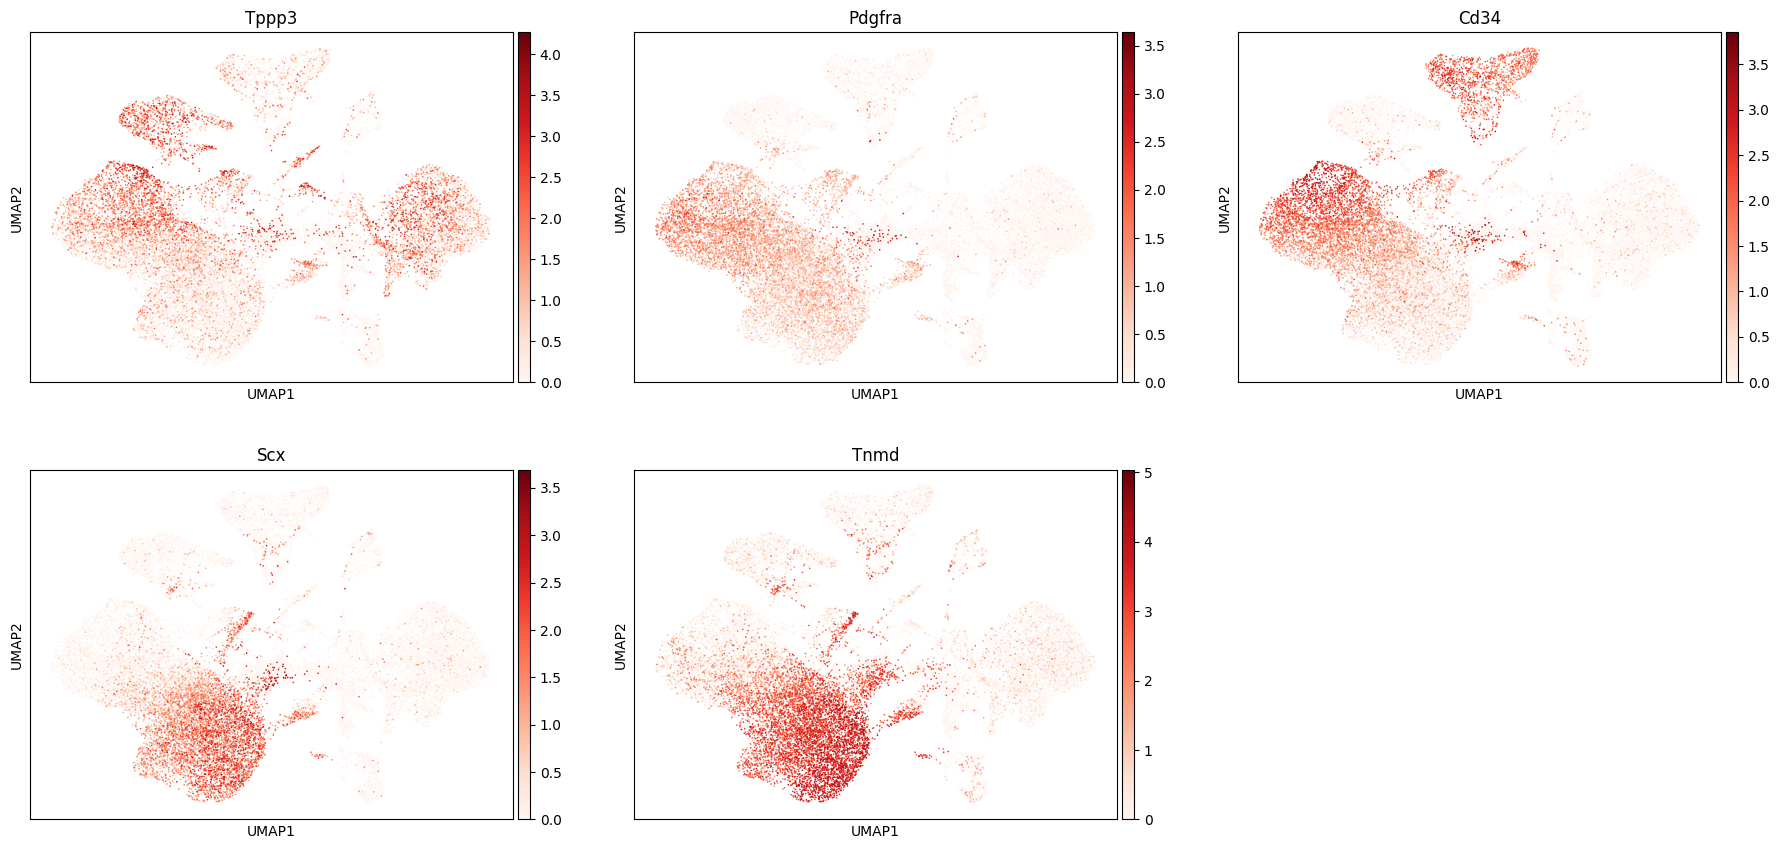

In [10]:
sc.pl.umap(adata, color=['Tppp3', 'Pdgfra', 'Cd34', 'Scx', 'Tnmd'],
           ncols=3, cmap='Reds', save='_markers.png')

**UMAP — TSPC and fate marker genes** (`umap_markers.png`)

These five genes trace the TSPC-to-tenocyte axis — the regenerative trajectory that is the core of this project.

- **Tppp3:** Enriched in the mesenchymal progenitor region of the UMAP, spanning clusters 8, 9, and 7. Cluster 9 has the highest mean Tppp3 expression, and cluster 8 is comparable. Tppp3 is low in immune (clusters 0, 1, 2, 13) and endothelial (clusters 10, 12) populations, confirming its mesenchymal progenitor identity. However, Tppp3 alone does not isolate cluster 8 — cluster 8 is the primary TSPC/T-FAP compartment because it is the only cluster combining Tppp3 with Cd34, Cd248, Tnxb, Pdgfra, Pi16, and Sfrp2 at high fractions simultaneously (see dotplot). This is the gene Harvey 2019 used to define and lineage-trace TSPCs.

- **Pdgfra:** Broadly expressed across the mesenchymal mass (frac 0.87 in cluster 8, and also present in clusters 4, 5, 6, and 7 at fractions 0.39–0.65). This breadth is expected — PDGFRα marks both TSPCs and T-FAPs, which is why Tppp3 co-expression is needed to distinguish them. Cells that are Pdgfra+ but Tppp3− are the T-FAP candidates.

- **Cd34:** Diffuse across multiple mesenchymal clusters (frac 0.88 in cluster 8, 0.85 in cluster 10). Marks broad stromal progenitor identity rather than a single population. Confirms that cluster 8 is a progenitor, but Cd34 alone cannot isolate it.

- **Scx:** Strongly enriched in tenocyte clusters 4 and 5 (frac 0.87 and 0.82 respectively), appearing in a distinct region of the UMAP separated from the Tppp3+ area. Scx is the master transcription factor of tendon fate — its spatial separation from Tppp3 on the UMAP represents the TSPC-to-tenocyte differentiation axis we aim to model with CellRank.

- **Tnmd:** Co-localises with Scx on the UMAP (frac 0.95 in cluster 4) and marks fully mature tenocytes. The progression Tppp3+ → Scx+ → Tnmd+ visible across the UMAP layout is the regenerative trajectory. Loss of this progression under denervation (TrkAF592A) is the central finding of the paper.

**Together**, these five markers map the full regenerative axis: TSPC identity (Tppp3), progenitor field (Pdgfra, Cd34), and terminal differentiation (Scx → Tnmd). The spatial separation between the Tppp3+ and Tnmd+ regions on the UMAP gives a visual preview of the fate trajectory to be quantified in downstream CellRank analysis.

## 7. Condition split — innervated vs denervated

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\2669474651.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color='condition', save='_condition.png')


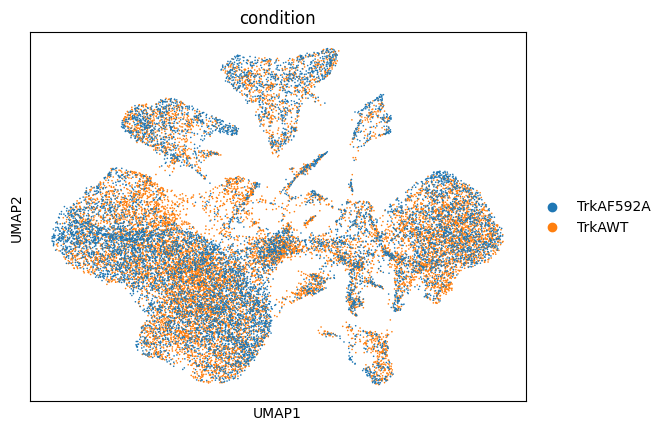

C:\Users\fangy\AppData\Local\Temp\ipykernel_30864\2669474651.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props = (adata.obs.groupby(['condition', 'leiden'])


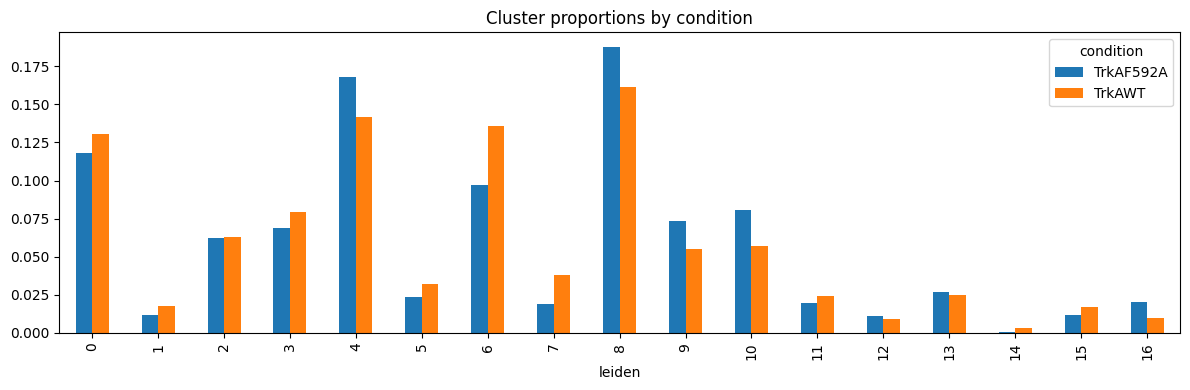

In [11]:
sc.pl.umap(adata, color='condition', save='_condition.png')

# Cell type proportions per condition
props = (adata.obs.groupby(['condition', 'leiden'])
               .size()
               .unstack(fill_value=0)
               .apply(lambda x: x / x.sum(), axis=1))
ax = props.T.plot(kind='bar', figsize=(12, 4), title='Cluster proportions by condition')
plt.tight_layout()
plt.savefig('../../figures/Cherief_scRNA-seq/cluster_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

**Condition split — UMAP and cluster proportions** (`umap_condition.png`, `cluster_proportions.png`)

- **UMAP by condition:** TrkAWT (orange) and TrkAF592A (blue) cells mix throughout the embedding, confirming that both conditions share the same cell type landscape. No large region is entirely one colour, ruling out a wholesale loss of a cell type in the denervated condition.

- **Cluster proportions bar chart:** Reveals subtler shifts in cell type abundance between conditions. Notable observations:
  - **Cluster 6** is proportionally higher in TrkAWT (~13%) than TrkAF592A (~10%) — this cluster overlaps with pretenocyte/tenocyte markers and may reflect reduced tenocyte differentiation under denervation.
  - **Cluster 7** is notably depleted in TrkAF592A (~2%) relative to TrkAWT (~4%).
  - **Cluster 8** (TSPC) is slightly higher in TrkAF592A (~18%) than TrkAWT (~16%) — consistent with the paper's finding that denervation *blocks TSPC expansion*, meaning TSPCs may accumulate without differentiating.
  - **Cluster 14** is essentially absent in TrkAF592A (only a small orange bar) — a rare population worth investigating further.

These proportional shifts are the quantitative basis for the biological story in Cherief et al.: denervation disrupts the normal progression from TSPC → tenocyte.

## 8. Save processed object

In [12]:
adata.write('../../data/Cherief_scRNA-seq/GSE244921_processed.h5ad')
print('Saved.')

Saved.
